---
# 3차시 — 비디오 감정 분석: Two-Stream / CNN+LSTM / C3D / I3D

| 모델 | 핵심 아이디어 |
|---|---|
| **Two-Stream** | 외모(RGB) 따로, 움직임(Optical Flow) 따로 → 합산 |
| **CNN+LSTM** | 프레임별 CNN 특징 → LSTM으로 시간 패턴 학습 |
| **C3D** | 3D Conv 필터로 시공간을 한번에 처리 |
| **I3D** (과제) | C3D + Inception 구조 확장 |

## 3-1. 라이브러리 불러오기

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import random
import os
import glob
import pandas as pd
import cv2

## 3-2. 시드 고정

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

print(f"Seed fixed: {SEED}")

Seed fixed: 42


## 3-3. 데이터 준비 — 라벨 로드

In [3]:
ROOT_PATH = "C:\\Users\\User\\Desktop\\deeplearning\\Raw"
# --- 라벨 CSV ---
label_path = f"{ROOT_PATH}/mosi_audio_metadata.csv"
label_df = pd.read_csv(label_path)

label_dict = {}
for _, row in label_df.iterrows():
    key = os.path.splitext(row["file_name"])[0]
    label_dict[key] = row["sentiment"]

print(f"라벨 수: {len(label_dict)}")

라벨 수: 2199


## 3-4. 비디오 클립 구성

2차시에서는 프레임 1장씩 독립적으로 처리했지만,  
3차시에서는 **여러 프레임을 하나의 클립으로** 묶어 시간 정보를 활용합니다.  

- `NUM_FRAMES = 16`: 클립당 샘플링할 프레임 수  
- `IMG_SIZE = 64`: 비디오 모델용 입력 크기 (224보다 작아 메모리 절약)

In [4]:
NUM_FRAMES = 16   # 클립당 프레임 수
IMG_SIZE = 64      # 각 프레임 크기 (64x64, 메모리 절약)

# --- 비디오 폴더 (Segmented) ---
video_folder = f"{ROOT_PATH}/Video/Segmented"
video_files = sorted(glob.glob(os.path.join(video_folder, "*.mp4")))
print(f"비디오 파일 수: {len(video_files)}")

비디오 파일 수: 2199


In [5]:
def extract_frames(video_path, num_frames=16, img_size=64):
    """비디오에서 등간격으로 num_frames장 추출 (순차 읽기로 최적화)"""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None

    # 등간격 인덱스
    indices = set(np.linspace(0, total - 1, num_frames, dtype=int))
    frames = []
    for i in range(total):
        ret, frame = cap.read()
        if not ret:
            break
        if i in indices:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            frames.append(frame)
        if len(frames) == num_frames:
            break
    cap.release()

    # 프레임 부족 시 마지막 프레임 반복
    if len(frames) == 0:
        return None
    while len(frames) < num_frames:
        frames.append(frames[-1])

    return frames[:num_frames]

In [6]:
# --- 비디오 클립 + 라벨 구성 ---
clips = []       # (T, H, W, 3) list
clip_labels = []

for vpath in video_files:
    fname = os.path.splitext(os.path.basename(vpath))[0]
    if fname not in label_dict:
        continue
    label = 1 if label_dict[fname] >= 0 else 0

    frames = extract_frames(vpath, NUM_FRAMES, IMG_SIZE)
    if frames is None or len(frames) < NUM_FRAMES:
        continue

    clips.append(frames)
    clip_labels.append(label)

print(f"클립 수: {len(clips)}")
print(f"긍정: {sum(clip_labels)}, 부정: {len(clip_labels) - sum(clip_labels)}")

클립 수: 2199
긍정: 1176, 부정: 1023


## 3-5. Dataset & DataLoader

- **비디오 클립**: `(B, 3, T, H, W)` — Two-Stream, CNN+LSTM, C3D, I3D 용  

In [7]:
def prepare_clip_tensor(frames):
    """프레임 리스트 → (3, T, H, W) float tensor"""
    arr = np.stack(frames, axis=0)               # (T, H, W, 3)
    arr = arr.astype(np.float32) / 255.0
    arr = arr.transpose(3, 0, 1, 2)              # (3, T, H, W)
    return arr

In [8]:
# --- numpy 변환 ---
X_clips = np.array([prepare_clip_tensor(c) for c in clips])  # (N, 3, T, H, W)
y_all   = np.array(clip_labels)

# 원본 삭제로 메모리 절약
del clips
import gc; gc.collect()

print(f"X_clips shape: {X_clips.shape}")
print(f"y shape: {y_all.shape}")

X_clips shape: (2199, 3, 16, 64, 64)
y shape: (2199,)


In [9]:
# --- Train / Test 분리 ---
idx_train, idx_test = train_test_split(
    np.arange(len(y_all)), test_size=0.2, random_state=42, stratify=y_all
)

X_clip_train = torch.tensor(X_clips[idx_train], dtype=torch.float32)
X_clip_test  = torch.tensor(X_clips[idx_test],  dtype=torch.float32)
y_train = torch.tensor(y_all[idx_train], dtype=torch.long)
y_test  = torch.tensor(y_all[idx_test],  dtype=torch.long)

print(f"Train: {len(y_train)}개, Test: {len(y_test)}개")

Train: 1759개, Test: 440개


In [10]:
class VideoClipDataset(Dataset):
    """모든 모델 공용 (Two-Stream, C3D, CNN+LSTM, I3D)"""
    def __init__(self, clips, labels):
        self.clips = clips
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.clips[idx], self.labels[idx]

In [11]:
BATCH_SIZE = 32

# --- 모든 모델 공용 DataLoader ---
train_gen = torch.Generator().manual_seed(SEED)
clip_train_loader = DataLoader(
    VideoClipDataset(X_clip_train, y_train),
    batch_size=BATCH_SIZE, shuffle=True, generator=train_gen
)
clip_test_loader = DataLoader(
    VideoClipDataset(X_clip_test, y_test),
    batch_size=BATCH_SIZE, shuffle=False
)

print(f"Train 배치: {len(clip_train_loader)}, Test 배치: {len(clip_test_loader)}")

Train 배치: 55, Test 배치: 14


## 3-6. 학습 / 평가 / 시각화 함수

2차시의 `train_model`, `evaluate_model`, `plot_training_results`를 그대로 재활용.  
Two-Stream만 입력이 2개이므로 별도 함수 추가.

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

def train_model(model, train_loader, criterion, optimizer, num_epochs, device):
    """2차시와 동일한 학습 함수 (video clip용)"""
    train_losses = []
    train_accs = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

        epoch_loss = running_loss / total
        epoch_acc = correct / total * 100
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.1f}%")

    print("학습 완료!")
    return train_losses, train_accs

device: cuda


In [13]:
def evaluate_model(model, data_loader, criterion, device):
    """2차시와 동일한 평가 함수"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            running_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

    test_loss = running_loss / total
    test_acc = correct / total * 100
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.1f}%")
    return test_loss, test_acc

In [14]:
fig_compare, axes_compare = plt.subplots(1, 2, figsize=(14, 5))
plt.close(fig_compare)  # 선언 시 바로 출력 방지

def plot_training_results(train_losses, train_accs, num_epochs, test_acc=None, title=""):
    """호출할 때마다 같은 그래프에 누적"""
    epochs = range(1, num_epochs + 1)
    axes_compare[0].plot(epochs, train_losses, marker="o", label=title)
    axes_compare[1].plot(epochs, train_accs, marker="o",
                        label=f"{title} (Test: {test_acc:.1f}%)" if test_acc else title)
    for ax in axes_compare:
        ax.legend()
        ax.grid(True, alpha=0.3)
    axes_compare[0].set_xlabel("Epoch"); axes_compare[0].set_ylabel("Loss")
    axes_compare[0].set_title("Training Loss")
    axes_compare[1].set_xlabel("Epoch"); axes_compare[1].set_ylabel("Accuracy (%)")
    axes_compare[1].set_title("Training Accuracy")
    fig_compare.tight_layout()
    display(fig_compare)

---
## 3-7. Two-Stream Network (Simonyan & Zisserman, 2014)

외모 + 움직임, 각각 따로 CNN 돌린 뒤 합산  

```
RGB 프레임 1장  →  [Spatial CNN]  → score1 ─┐
                                           ├→ 합산 → 최종 예측
Optical Flow   →  [Temporal CNN] → score2 ─┘
```

In [26]:
class TwoStream(nn.Module):
    def __init__(self, num_classes=2, num_frames=16):
        super().__init__()

        # --- Spatial Stream: RGB 1장 (3채널) 공간축 ---
        self.s_conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.s_relu1 = nn.ReLU()
        self.s_pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.s_conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.s_relu2 = nn.ReLU()
        self.s_pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.s_gap = nn.AdaptiveAvgPool2d(1)
        self.s_fc = nn.Linear(64, num_classes)

        # --- Temporal Stream: Frame Diff (num_frames-1 채널) 시간축 ---
        self.t_conv1 = nn.Conv2d(in_channels=num_frames - 1, out_channels=32, kernel_size=3, padding=1)
        self.t_relu1 = nn.ReLU()
        self.t_pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.t_conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.t_relu2 = nn.ReLU()
        self.t_pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.t_gap = nn.AdaptiveAvgPool2d(1)
        self.t_fc = nn.Linear(64, num_classes)

    def forward(self, x):
        B, C, T, H, W = x.shape

        # Spatial: 중간 프레임 1장
        rgb = x[:, :, T // 2]
        rgb = self.s_pool1(self.s_relu1(self.s_conv1(rgb)))
        rgb = self.s_pool2(self.s_relu2(self.s_conv2(rgb)))
        rgb = self.s_gap(rgb).flatten(1)
        score1 = self.s_fc(rgb)

        # Temporal: 흑백 → 프레임 차이
        gray = x.mean(dim=1)  # (B, T, H, W)
        diffs = gray[:, 1:] - gray[:, :-1]  # (B, T-1, H, W)
        diffs = self.t_pool1(self.t_relu1(self.t_conv1(diffs)))
        diffs = self.t_pool2(self.t_relu2(self.t_conv2(diffs)))
        diffs = self.t_gap(diffs).flatten(1)
        score2 = self.t_fc(diffs)

        return (score1+ score2)/2


model_ts = TwoStream(num_classes=2, num_frames=NUM_FRAMES).to(device)
print(f"Two-Stream 파라미터: {sum(p.numel() for p in model_ts.parameters()):,}")

Two-Stream 파라미터: 42,500


In [27]:
criterion_ts = nn.CrossEntropyLoss()
optimizer_ts = optim.Adam(model_ts.parameters(), lr=0.001)
num_epochs = 10

In [28]:
ts_losses, ts_accs = train_model(
    model_ts, clip_train_loader, criterion_ts, optimizer_ts, num_epochs, device
)

Epoch [5/10]  Loss: 0.6764  Acc: 57.4%
Epoch [10/10]  Loss: 0.6666  Acc: 59.0%
학습 완료!


In [29]:
ts_test_loss, ts_test_acc = evaluate_model(
    model_ts, clip_test_loader, criterion_ts, device
)

Test Loss: 0.7093
Test Accuracy: 51.8%


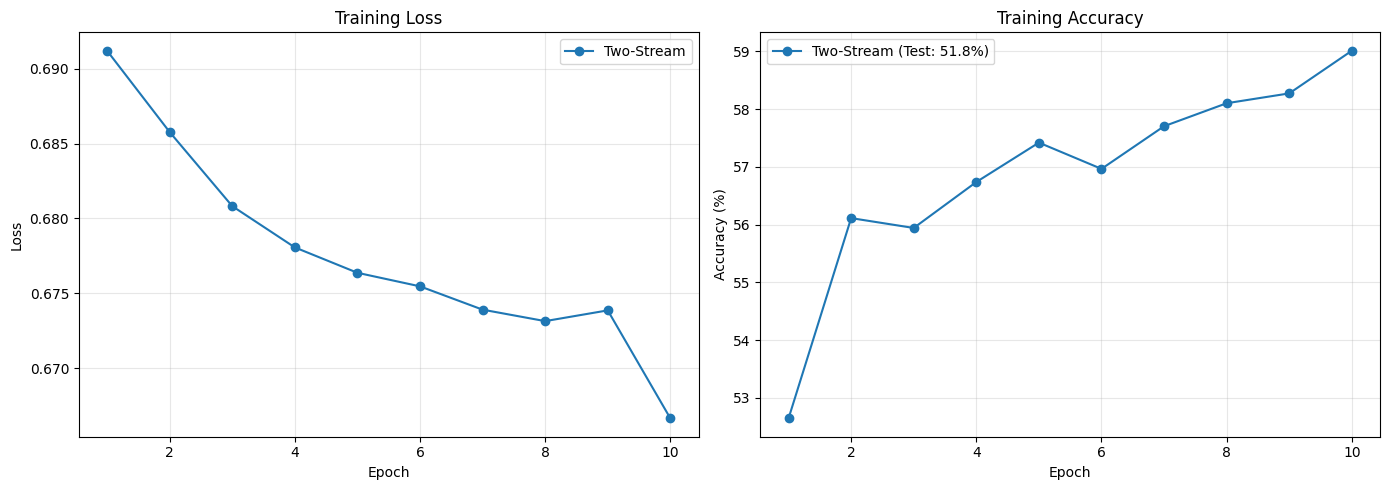

In [30]:
plot_training_results(ts_losses, ts_accs, num_epochs, test_acc=ts_test_acc, title="Two-Stream")

---
## 3-8. CNN + LSTM (Donahue et al., 2015)

이미지 차시의 CNN + 텍스트/오디오 차시의 LSTM을 연결  
Optical Flow 없이도 **시간 정보**를 활용할 수 있음  

```
프레임1 → [CNN] → 특징1 ─┐
프레임2 → [CNN] → 특징2 ─┤
  ...                  │→ [LSTM] → 분류
프레임T → [CNN] → 특징T ─┘
```

In [31]:
class CNN_LSTM(nn.Module):
    def __init__(self, num_classes=2, hidden_size=128):
        super().__init__()

        # CNN: 프레임 1장 → 특징 벡터 128개
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.gap = nn.AdaptiveAvgPool2d(1)

        # LSTM: 프레임 순서대로 들어온 특징들을 보고 시간 패턴 학습
        self.lstm = nn.LSTM(input_size=128, hidden_size=hidden_size, num_layers=2, batch_first=True)

        # 분류기
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        B, C, T, H, W = x.shape

        # 모든 프레임을 한번에 CNN 통과
        frames = x.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)  # (B*T, C, H, W)
        frames = self.pool1(self.relu1(self.conv1(frames)))
        frames = self.pool2(self.relu2(self.conv2(frames)))
        frames = self.relu3(self.conv3(frames))
        frames = self.gap(frames).flatten(1)  # (B*T, 128)
        features = frames.reshape(B,T,-1)

        # LSTM → 마지막 hidden state로 분류
        _, (h_n, _) = self.lstm(features)
        return self.fc(h_n[-1])  # 마지막 층의 hidden state로 분류


model_cl = CNN_LSTM(num_classes=2).to(device)
print(f"CNN+LSTM 파라미터: {sum(p.numel() for p in model_cl.parameters()):,}")

CNN+LSTM 파라미터: 357,698


In [32]:
criterion_cl = nn.CrossEntropyLoss()
optimizer_cl = optim.Adam(model_cl.parameters(), lr=0.001)
num_epochs = 10

In [33]:
cl_losses, cl_accs = train_model(
    model_cl, clip_train_loader, criterion_cl, optimizer_cl, num_epochs, device
)

Epoch [5/10]  Loss: 0.6909  Acc: 53.2%
Epoch [10/10]  Loss: 0.6909  Acc: 53.5%
학습 완료!


In [34]:
cl_test_loss, cl_test_acc = evaluate_model(
    model_cl, clip_test_loader, criterion_cl, device
)

Test Loss: 0.6912
Test Accuracy: 53.4%


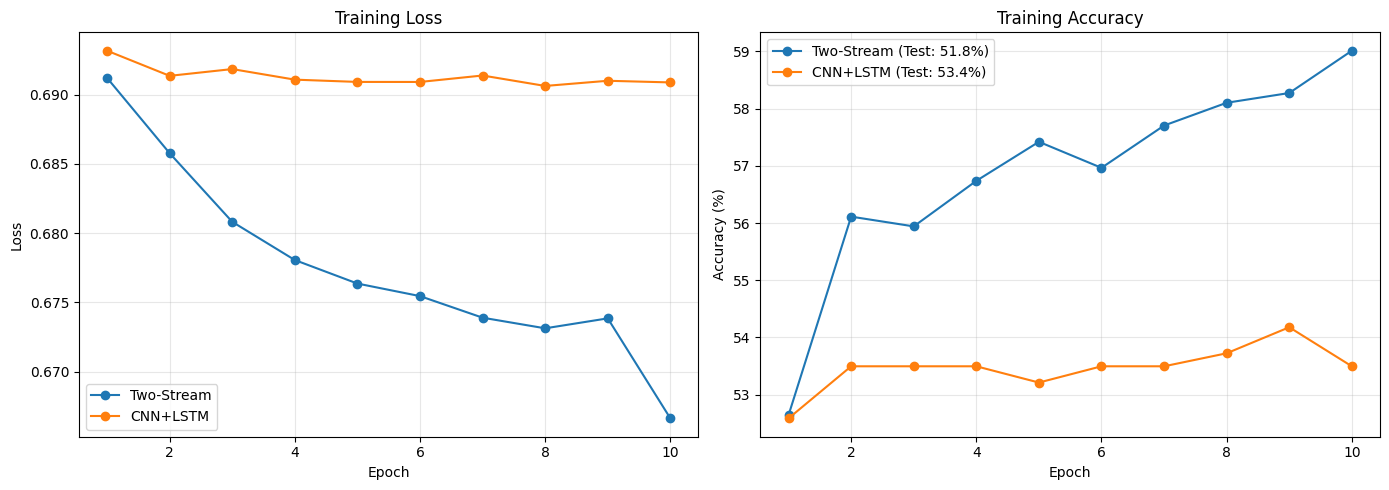

In [35]:
plot_training_results(cl_losses, cl_accs, num_epochs, test_acc=cl_test_acc, title="CNN+LSTM")

---
## 3-9. C3D (Tran et al., 2015)

2D 필터(H×W) 대신 **3D 필터(T×H×W)** 로 시공간을 한번에 학습  
`nn.Conv2d` → `nn.Conv3d` 로 바꾸는 것만으로 구현 가능  

```
2D Conv: 이미지 한 장에서 공간 패턴  → (H, W) 필터
3D Conv: 여러 프레임에서 시공간 패턴 → (T, H, W) 필터
```

In [36]:
class C3D(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        # 3D Conv: kernel_size=(시간, 높이, 너비)
        self.conv1 = nn.Conv3d(in_channels=3, out_channels=32, kernel_size=(3,3,3), padding=(1,1,1))
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool3d(kernel_size=(2,2,2))

        self.conv2 = nn.Conv3d(in_channels=32, out_channels=64, kernel_size=(3,3,3), padding=(1,1,1))
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool3d(kernel_size=(2,2,2))

        self.conv3 = nn.Conv3d(in_channels=64, out_channels=128, kernel_size=(3,3,3), padding=(1,1,1))
        self.relu3 = nn.ReLU()
        self.gap = nn.AdaptiveAvgPool3d(1)

        # 분류기
        self.fc1 = nn.Linear(128, 64)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.gap(self.relu3(self.conv3(x)))
        x = x.flatten(1)
        x = self.dropout(self.relu4(self.fc1(x)))
        x = self.fc2(x)
        return x

model_c3d = C3D(num_classes=2).to(device)
print(f"C3D 파라미터: {sum(p.numel() for p in model_c3d.parameters()):,}")

C3D 파라미터: 287,682


In [37]:
criterion_c3d = nn.CrossEntropyLoss()
optimizer_c3d = optim.Adam(model_c3d.parameters(), lr=0.001)
num_epochs = 10

In [38]:
c3d_losses, c3d_accs = train_model(
    model_c3d, clip_train_loader, criterion_c3d, optimizer_c3d, num_epochs, device
)

c:\Users\User\miniconda3\envs\main\lib\site-packages\torch\autograd\graph.py:869: UserWarning: max_pool3d_with_indices_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [5/10]  Loss: 0.6915  Acc: 52.6%
Epoch [10/10]  Loss: 0.6918  Acc: 52.5%
학습 완료!


In [39]:
c3d_test_loss, c3d_test_acc = evaluate_model(
    model_c3d, clip_test_loader, criterion_c3d, device
)

Test Loss: 0.6926
Test Accuracy: 53.4%


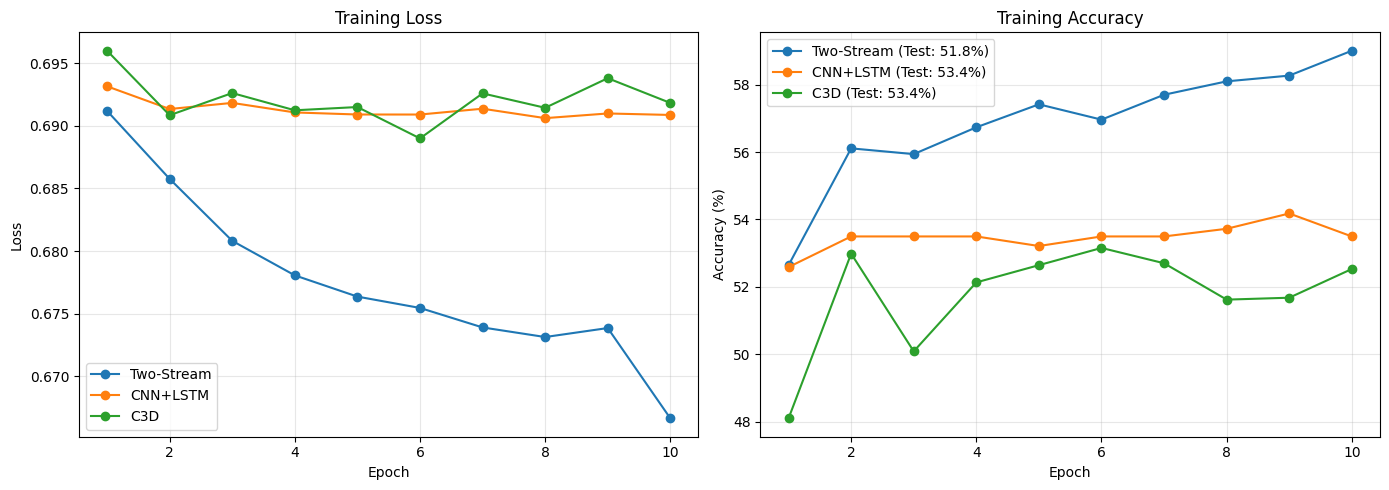

In [40]:
plot_training_results(c3d_losses, c3d_accs, num_epochs, test_acc=c3d_test_acc, title="C3D")

---
## 3-9b. Simple Inception 3D (2-Branch)

I3D로 가기 전에, **Inception 구조의 핵심 아이디어**를 먼저 연습합니다.  
C3D는 한 가지 크기의 필터만 사용했지만, Inception은 **여러 크기의 필터를 동시에** 적용합니다.

```
         ┌─ [1×1×1 Conv] ─────────────┐
입력 ────┤                              ├─ concat → 출력
         └─ [1×1×1 Conv] → [3×3×3 Conv] ┘
```

- Branch 1: 1×1×1 필터 → 전체적인 특징 (채널 압축)
- Branch 2: 1×1×1 → 3×3×3 필터 → 주변 시공간 패턴

In [42]:
class SimpleInceptionBlock3D(nn.Module):
    """Inception: 2개 Branch만 사용"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        mid = out_ch // 2

        # Branch 1: 1×1×1 필터 (채널 압축)
        self.b1_conv = nn.Conv3d(in_channels=in_ch, out_channels=mid, kernel_size=1)
        self.b1_relu = nn.ReLU()

        # Branch 2: 1×1×1 → 3×3×3 필터 (주변 시공간 패턴)
        self.b2_conv1 = nn.Conv3d(in_channels=in_ch, out_channels=mid, kernel_size=1)
        self.b2_relu1 = nn.ReLU()
        self.b2_conv2 = nn.Conv3d(in_channels=mid, out_channels=mid, kernel_size=3, padding=1)
        self.b2_relu2 = nn.ReLU()

    def forward(self, x):
        b1 = self.b1_relu(self.b1_conv(x))
        b2 = self.b2_relu2(self.b2_conv2(self.b2_relu1(self.b2_conv1(x))))
        # 2개 branch 결과를 채널 방향으로 합침
        return torch.cat([b1, b2], dim=1)


class SimpleI3D(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        # Stem: 초기 특징 추출
        self.stem_conv = nn.Conv3d(in_channels=3, out_channels=32, kernel_size=(3,7,7), stride=(1,2,2), padding=(1,3,3))
        self.stem_bn = nn.BatchNorm3d(32)
        self.stem_relu = nn.ReLU()
        self.stem_pool = nn.MaxPool3d(kernel_size=(1,3,3), stride=(1,2,2), padding=(0,1,1))

        # 2-Branch Inception Blocks
        self.inception1 = SimpleInceptionBlock3D(in_ch=32, out_ch=64) 
        self.inception2 = SimpleInceptionBlock3D(in_ch=64, out_ch=128)
        self.gap = nn.AdaptiveAvgPool3d(1)

        # 분류기
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.stem_pool(self.stem_relu(self.stem_bn(self.stem_conv(x))))
        x = self.inception1(x)
        x = self.inception2(x)
        x = self.gap(x).flatten(1)
        x = self.fc(self.dropout(x))
        return x


model_si3d = SimpleI3D(num_classes=2).to(device)
print(f"Simple I3D (2-Branch) 파라미터: {sum(p.numel() for p in model_si3d.parameters()):,}")

Simple I3D (2-Branch) 파라미터: 163,234


In [43]:
criterion_si3d = nn.CrossEntropyLoss()
optimizer_si3d = optim.Adam(model_si3d.parameters(), lr=0.001)
num_epochs = 10

In [44]:
si3d_losses, si3d_accs = train_model(
    model_si3d, clip_train_loader, criterion_si3d, optimizer_si3d, num_epochs, device
)

Epoch [5/10]  Loss: 0.6730  Acc: 56.7%
Epoch [10/10]  Loss: 0.6513  Acc: 60.3%
학습 완료!


In [45]:
si3d_test_loss, si3d_test_acc = evaluate_model(
    model_si3d, clip_test_loader, criterion_si3d, device
)

Test Loss: 0.6767
Test Accuracy: 53.2%


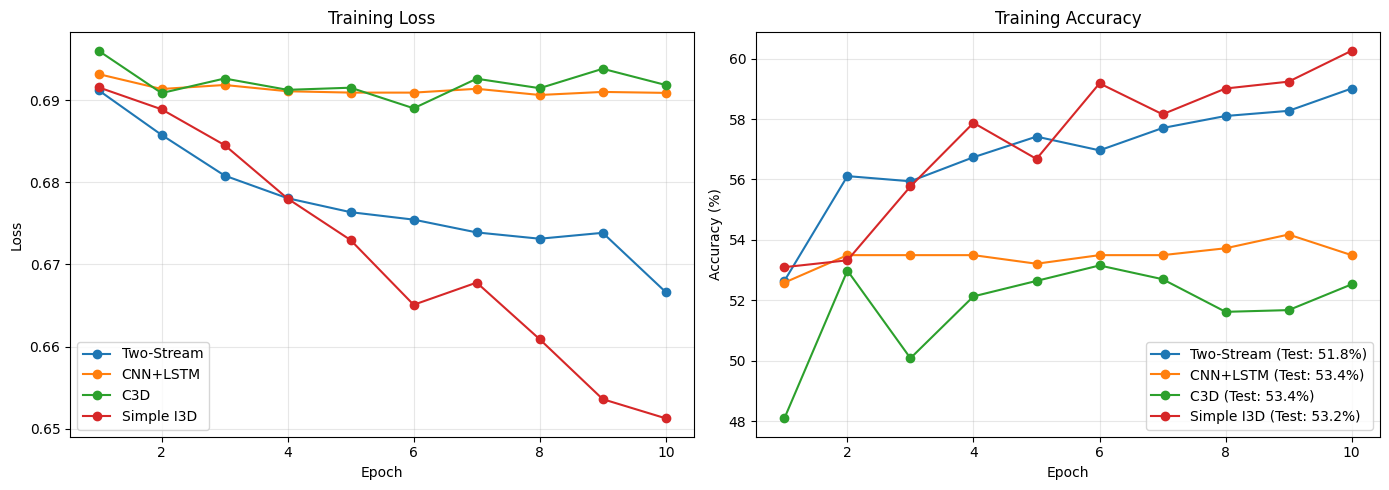

In [46]:
plot_training_results(si3d_losses, si3d_accs, num_epochs, test_acc=si3d_test_acc, title="Simple I3D")

---
## 3-10. I3D (과제)

C3D 구조에 **Inception 모듈**을 적용한 확장 모델  

- `InceptionBlock3D`: 여러 크기의 3D 필터를 **병렬로** 적용 후 채널 방향으로 합침  
- 1×1×1, 3×3×3, 5×5×5, MaxPool → 4개 branch 결과를 concat  

> 힌트: C3D를 이해했으면 `Conv3d`를 여러 크기로 병렬하는 것만 추가하면 됩니다!

In [96]:
class InceptionBlock3D(nn.Module):
    """I3D의 핵심: 여러 크기의 3D 필터를 병렬로 적용 후 합침"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        mid = out_ch // 4

        # Branch 1: 1×1×1 필터 (채널 압축)
        self.b1_conv = nn.Conv3d(in_channels=in_ch, out_channels=mid, kernel_size=(1, 1, 1))
        self.b1_relu = nn.ReLU()

        # Branch 2: 1×1×1 → 3×3×3 필터
        self.b2_conv1 = nn.Conv3d(in_channels=in_ch, out_channels=mid, kernel_size=(1, 1, 1))
        self.b2_relu1 = nn.ReLU()
        self.b2_conv2 = nn.Conv3d(in_channels=mid, out_channels=mid, kernel_size=(3, 3, 3), padding=(1, 1, 1))
        self.b2_relu2 = nn.ReLU()

        # Branch 3: 1×1×1 → 5×5×5 필터
        self.b3_conv1 = nn.Conv3d(in_channels=in_ch, out_channels=mid, kernel_size=(1, 1, 1))
        self.b3_relu1 = nn.ReLU()
        self.b3_conv2 = nn.Conv3d(in_channels=mid, out_channels=mid, kernel_size=(5, 5, 5), padding=(2, 2, 2))
        self.b3_relu2 = nn.ReLU()

        # Branch 4: MaxPool → 1×1×1 필터
        self.bp_pool = nn.MaxPool3d(kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        self.bp_conv = nn.Conv3d(in_channels=in_ch, out_channels=mid, kernel_size=(1, 1, 1))
        self.bp_relu = nn.ReLU()

    def forward(self, x):
        b1 = self.b1_relu(self.b1_conv(x))
        b2 = self.b2_relu2(self.b2_conv2(self.b2_relu1(self.b2_conv1(x))))
        b3 = self.b3_relu2(self.b3_conv2(self.b3_relu1(self.b3_conv1(x))))
        bp = self.bp_relu(self.bp_conv(self.bp_pool(x)))
        # 4개 branch 결과를 채널 방향으로 합침
        #print('b1:',b1.shape,'b2:',b2.shape,'b3:',b3.shape,'bp:',bp.shape)
        return torch.cat([b1, b2, b3, bp], dim=1)


class I3D(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        # Stem: 초기 특징 추출
        self.stem_conv = nn.Conv3d(in_channels=3, out_channels=32,
                                   kernel_size=(3,7,7), stride=(1,2,2), padding=(1,3,3))
        self.stem_bn = nn.BatchNorm3d(32)
        self.stem_relu = nn.ReLU()
        self.stem_pool = nn.MaxPool3d(kernel_size=(1,3,3), stride=(1,2,2), padding=(0,1,1))

        # Inception Blocks
        self.inception1 = InceptionBlock3D(in_ch=32, out_ch=64)
        self.inception2 = InceptionBlock3D(in_ch=64, out_ch=128)
        self.gap = nn.AdaptiveAvgPool3d(1)

        # 분류기
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        """
        x: (B, 3, T, H, W) - RGB 동영상
        """
        x = self.stem_pool(self.stem_relu(self.stem_bn(self.stem_conv(x))))
        x = self.inception1(x)
        x = self.inception2(x)
        x = self.gap(x).flatten(1)
        #print('x:',x.shape)
        x = self.fc(self.dropout(x))               # (B, num_classes)
        return x


model_i3d = I3D(num_classes=2).to(device)
print(f"I3D 파라미터: {sum(p.numel() for p in model_i3d.parameters()):,}")

I3D 파라미터: 219,554


In [97]:
# --- 과제: I3D 학습 & 평가 ---
criterion_i3d = nn.CrossEntropyLoss()
optimizer_i3d = optim.Adam(model_i3d.parameters(), lr=0.001)
num_epochs = 10

In [98]:
i3d_losses, i3d_accs = train_model(
    model_i3d, clip_train_loader, criterion_i3d, optimizer_i3d, num_epochs, device
)

Epoch [5/10]  Loss: 0.6725  Acc: 57.4%
Epoch [10/10]  Loss: 0.6563  Acc: 60.5%
학습 완료!


In [79]:
i3d_test_loss, i3d_test_acc = evaluate_model(
    model_i3d, clip_test_loader, criterion_i3d, device
)

Test Loss: 0.6549
Test Accuracy: 58.9%


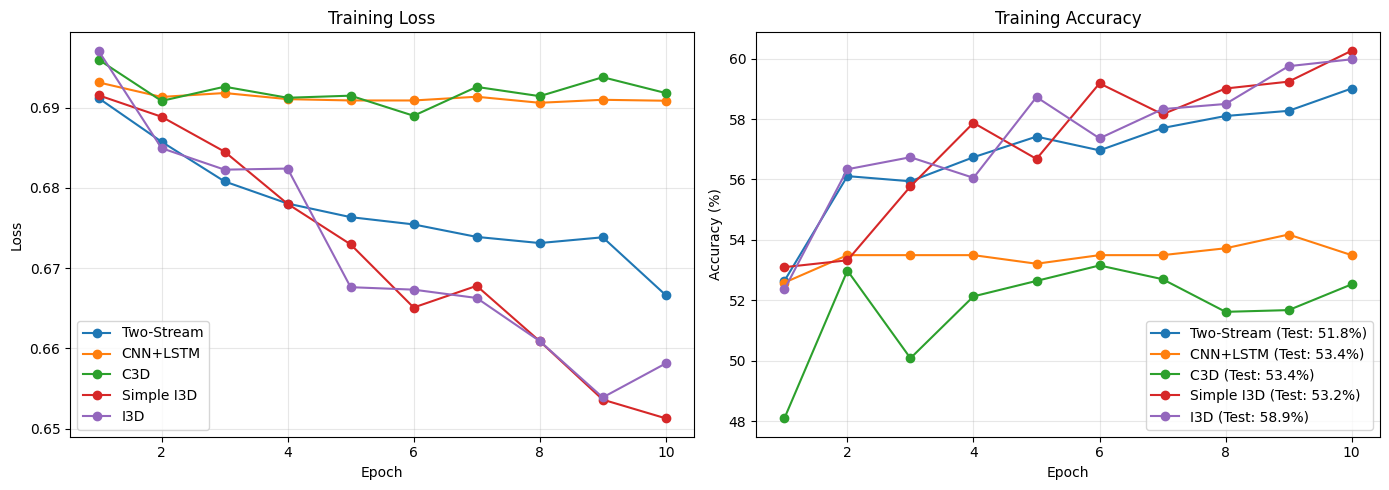

In [80]:
plot_training_results(i3d_losses, i3d_accs, num_epochs, test_acc=i3d_test_acc, title="I3D")